In [ ]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
import cv2
import torch
import albumentations as A
# from albumentations.pytorch import ToTensorV2
from torch.utils.data import DataLoader, Dataset
from collections import Counter
from PIL import Image
import numpy as np
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
# from collections import defaultdict
import random
from torchvision import transforms
import torchvision.transforms.functional as F
from sklearn.model_selection import train_test_split
import torch.optim as optim

c:\Users\alexa\Documents\BINUS - COMPUTER SCIENCE\Semester 4\Machine Learning\U-Net Model Real\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\alexa\Documents\BINUS - COMPUTER SCIENCE\Semester 4\Machine Learning\U-Net Model Real\.venv\Lib\site-packages\albumentations\__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.7'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [2]:
img_path = 'image_dataset/original'
masked_path = 'image_dataset/masked'
new_masked_path = 'image_dataset/new_masked'

In [4]:
img_lists = sorted([os.path.join(img_path,f) for f in list(os.listdir(img_path))])
masked_lists = sorted([os.path.join(masked_path,f)  for f in list(os.listdir(masked_path))])
new_masked = sorted([os.path.join(new_masked_path,f)  for f in list(os.listdir(new_masked_path))])

In [5]:
print(len(img_lists))
print(len(masked_lists))

8024
8024


# Mapping Masks into 3 Classes (Background[0],Crop[1],Weed[2])

In [ ]:
# These are the label IDs used in current masks
CROP_IDS = [1, 2, 3, 4, 5, 6, 7, 13, 15, 18, 24, 26, 27, 94]  # crop classes (pixel values)
BACKGROUND_IDS = [0, 255]  # background classes

# Weed = everything else
ALL_POSSIBLE_IDS = list(range(0, 256))  
WEED_IDS = list(set(ALL_POSSIBLE_IDS) - set(CROP_IDS) - set(BACKGROUND_IDS))


In [ ]:
def remap_mask(mask):
    # Create empty mask with same size
    new_mask = np.zeros_like(mask, dtype=np.uint8)

    new_mask[np.isin(mask, BACKGROUND_IDS)] = 0  # Background
    new_mask[np.isin(mask, CROP_IDS)] = 1        # Crop
    new_mask[np.isin(mask, WEED_IDS)] = 2        # Weed

    return new_mask

for mask_path in tqdm(masked_lists, desc="Remapping masks"):
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    new_mask = remap_mask(mask)

    filename = os.path.basename(mask_path)
    save_path = os.path.join(new_masked_path, filename)
    cv2.imwrite(save_path, new_mask * 127)


Remapping masks: 100%|██████████| 8024/8024 [06:24<00:00, 20.86it/s]


# Class Distribution

In [19]:
img1 = cv2.imread(img_lists[15],cv2.IMREAD_COLOR_RGB)
img1.shape

(1088, 1920, 3)

In [21]:
mask = cv2.imread(new_masked[165], cv2.IMREAD_GRAYSCALE)
print("Unique mask values:", np.unique(mask))


Unique mask values: [  0 127 254]


In [23]:
image_class_presence = Counter()

for mask_path in tqdm(new_masked):
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE) // 127
    unique = np.unique(mask)
    for cls in unique:
        image_class_presence[cls] += 1

print("Number of images containing each class:")
print(image_class_presence)


100%|██████████| 8024/8024 [05:12<00:00, 25.65it/s]

Number of images containing each class:
Counter({np.uint8(0): 8024, np.uint8(2): 6296, np.uint8(1): 3955})


Text(0.5, 1.0, 'Class Distribution')

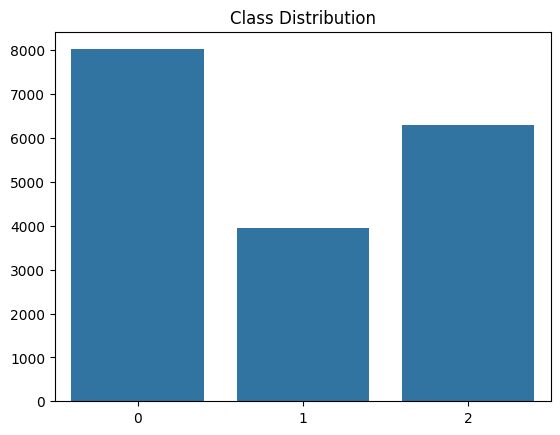

In [28]:
sns.barplot(x=image_class_presence.keys(),y=image_class_presence.values())
plt.title('Class Distribution')


In [70]:
image_class_presence

Counter({np.uint8(0): 8024, np.uint8(2): 6296, np.uint8(1): 3955})

# Oversampling

In [ ]:
oversampled_img_list = []
oversampled_mask_list = []

for image, mask_path in tqdm(zip(img_lists, new_masked)):
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    labels, counts = np.unique((mask // 127).astype(int), return_counts=True)

    # Mask out background counts by replacing them with -1 so argmax ignores background
    counts_masked = np.where(labels != 0, counts, -1)
    dominant_class = labels[np.argmax(counts_masked)]

    if dominant_class == 1:
        oversampled_img_list.append(image)
        oversampled_mask_list.append(mask_path)

print("Example oversampled mask:", oversampled_mask_list[1])
print("Example oversampled image:", oversampled_img_list[1])


8024it [03:38, 36.80it/s]

Example oversampled mask: image_dataset/new_masked\ave-0037-0009.png
Example oversampled image: image_dataset/original\ave-0037-0009.jpg


In [ ]:
needed_crop = 2341  # calculated before hand

# Combine image and mask paths into pairs
crop_pairs = list(zip(oversampled_img_list, oversampled_mask_list))

# Randomly sample with replacement from these pairs
oversampled_crop_pairs = random.choices(crop_pairs, k=needed_crop)

# Unzip back into separate lists
oversampled_img_list_new, oversampled_mask_list_new = zip(*oversampled_crop_pairs)

oversampled_img_list_new = list(oversampled_img_list_new)
oversampled_mask_list_new = list(oversampled_mask_list_new)

final_img_list = img_lists + oversampled_img_list_new
final_mask_list = new_masked + oversampled_mask_list_new

print(f"Original dataset size: {len(img_lists)}")
print(f"Oversampled crop size: {len(oversampled_img_list_new)}")
print(f"Final dataset size: {len(final_img_list)}")


Original dataset size: 8024
Oversampled crop size: 2341
Final dataset size: 10365


In [ ]:
from torchvision.transforms.functional import InterpolationMode
class SegmentationDataset(Dataset):
    def __init__(self, image_paths, mask_paths, augment=False):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.augment = augment

        # Changed target size to be divisible by 32 (288, 480)
        self.resize_img = transforms.Resize((288, 480), interpolation=InterpolationMode.BILINEAR)
        self.resize_mask = transforms.Resize((288, 480), interpolation=InterpolationMode.NEAREST)

        self.to_tensor = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])

        self.jitter = transforms.ColorJitter(brightness=0.2, contrast=0.2)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.image_paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)

        img = Image.fromarray(img)
        mask = Image.fromarray(mask)

        img = self.resize_img(img)
        mask = self.resize_mask(mask)

        # Data augmentation (applied per sample)
        if self.augment:
            if random.random() > 0.5:
                img = F.hflip(img)
                mask = F.hflip(mask)

            angle = random.uniform(-20, 20)
            img = F.rotate(img, angle, interpolation=InterpolationMode.BILINEAR, expand=False)
            mask = F.rotate(mask, angle, interpolation=InterpolationMode.NEAREST, expand=False)

            img = self.jitter(img)

        # Final image transform
        img = self.to_tensor(img)

        # Convert mask to tensor and remap values
        mask = np.array(mask)
        # Original values were 0, 1, 2. After multiplying by 127 and saving/loading:
        # 0 * 127 = 0
        # 1 * 127 = 127
        # 2 * 127 = 254
        mask[mask == 127] = 1
        mask[mask == 254] = 2

        mask = torch.from_numpy(mask).long()

        return img, mask


In [9]:
train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    final_img_list, final_mask_list, test_size=0.2, random_state=42, shuffle=True
)


In [11]:
# add the original images + masks AND the oversampled + masks
train_dataset = SegmentationDataset(train_imgs,train_masks,True)
val_dataset = SegmentationDataset(val_imgs,val_masks,False)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=0)


# U-Net Architecture

In [ ]:
# import torch.nn as nn

# class UNet(nn.Module):
#     def __init__(self, in_channels=3, out_channels=3):
#         super(UNet, self).__init__()

#         def conv_block(in_c, out_c):
#             return nn.Sequential(
#                 nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
#                 nn.ReLU(inplace=True),
#                 nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
#                 nn.ReLU(inplace=True)
#             )

#         self.down1 = conv_block(in_channels, 64)
#         self.pool1 = nn.MaxPool2d(2)
#         self.down2 = conv_block(64, 128)
#         self.pool2 = nn.MaxPool2d(2)

#         self.bottleneck = conv_block(128, 256)

#         self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
#         self.upconv2 = conv_block(256, 128)
#         self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
#         self.upconv1 = conv_block(128, 64)

#         self.final = nn.Conv2d(64, out_channels, kernel_size=1)

#     def forward(self, x):
#         d1 = self.down1(x)
#         p1 = self.pool1(d1)
#         d2 = self.down2(p1)
#         p2 = self.pool2(d2)

#         b = self.bottleneck(p2)

#         up2 = self.up2(b)
#         merge2 = torch.cat([up2, d2], dim=1)
#         u2 = self.upconv2(merge2)

#         up1 = self.up1(u2)
#         merge1 = torch.cat([up1, d1], dim=1)
#         u1 = self.upconv1(merge1)

#         return self.final(u1)


In [ ]:
def compute_class_weights(loader, num_classes, device):
    class_counts = np.zeros(num_classes, dtype=np.int64)
    total_pixels = 0
    
    for _, masks in tqdm(loader, desc="Computing class weights"):
        masks_np = masks.cpu().numpy()
        for c in range(num_classes):
            class_counts[c] += np.sum(masks_np == c)
        total_pixels += masks_np.size
    
    class_freq = class_counts / total_pixels
    # Avoid zero division
    class_freq = np.clip(class_freq, 1e-6, None)
    # Inverse frequency weights
    class_weights = 1 / class_freq
    # Normalize weights to sum=1 (optional)
    class_weights = class_weights / class_weights.sum()
    
    return torch.tensor(class_weights, dtype=torch.float32).to(device)


In [ ]:
import segmentation_models_pytorch as smp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model = smp.UnetPlusPlus(
    encoder_name="resnet34",        # resnet for now
    encoder_weights="imagenet",     # pretrained weightss
    in_channels=3,
    classes=3,                      # multi-class 0,1,2
    activation=None             
).to(device)


Using device: cuda


c:\Users\alexa\Documents\BINUS - COMPUTER SCIENCE\Semester 4\Machine Learning\U-Net Model Real\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\alexa\.cache\huggingface\hub\models--smp-hub--resnet34.imagenet. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


In [24]:
class_weights = torch.tensor([0.0074, 0.5437, 0.4489], device='cuda:0') # already calculated the class_weights beforehand
criterion = torch.nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=5e-5)


In [14]:
class_weights

tensor([0.0074, 0.5437, 0.4489], device='cuda:0')

In [25]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

scheduler = ReduceLROnPlateau(
    optimizer,
    mode='max',         # because higher IoU is better
    factor=0.5,         # reduce LR by half
    patience=2,        
    verbose=True
)


c:\Users\alexa\Documents\BINUS - COMPUTER SCIENCE\Semester 4\Machine Learning\U-Net Model Real\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [ ]:
def iou_score(preds, labels, num_classes):
    ious = []
    preds = preds.view(-1)
    labels = labels.view(-1)

    for cls in range(num_classes):
        pred_inds = (preds == cls)
        label_inds = (labels == cls)

        intersection = (pred_inds & label_inds).sum().item()
        union = (pred_inds | label_inds).sum().item()

        if union == 0:
            iou = float('nan')  # ignore this class if no pixels present
        else:
            iou = intersection / union
        ious.append(iou)

    return np.nanmean(ious), ious  # overall mean and list per class

def dice_coef(preds, labels, num_classes):
    dices = []
    preds = preds.view(-1)
    labels = labels.view(-1)

    for cls in range(num_classes):
        pred_inds = (preds == cls)
        label_inds = (labels == cls)

        intersection = (pred_inds & label_inds).sum().item()
        pred_sum = pred_inds.sum().item()
        label_sum = label_inds.sum().item()

        if pred_sum + label_sum == 0:
            dice = float('nan')
        else:
            dice = 2 * intersection / (pred_sum + label_sum)
        dices.append(dice)

    return np.nanmean(dices), dices


In [ ]:
iou_scores = []
dice_scores = []
iou_per_class_scores = []
dice_per_class_scores = []

def train_model(model, train_loader, val_loader, optimizer, criterion, device, scheduler, epochs=10, num_classes=3, save_dir="./checkpoints"):
    os.makedirs(save_dir, exist_ok=True)

    current_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {current_device}")
    model.to(current_device)

    best_iou = 0.7485 # current best one in the model

    # Load best model if exists
    best_model_path = os.path.join(save_dir, "best_model.pth")
    if os.path.exists(best_model_path):
        print(f"Loading best model from {best_model_path} to continue training...")
        map_location = current_device # Or 'cpu' if you always want to load to CPU first
        model.load_state_dict(torch.load(best_model_path, map_location=map_location))
        print("Model loaded successfully.")


    epochs+=20

    for epoch in range(20,epochs):
        model.train()
        train_loss = 0

        train_iter = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} - Training", leave=False)
        for images, masks in train_iter:
            # Move data to the current device
            images, masks = images.to(current_device), masks.to(current_device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            train_iter.set_postfix(loss=loss.item())

        avg_train_loss = train_loss / len(train_loader.dataset)

        # Validation
        model.eval()
        val_loss = 0
        epoch_iou_scores = []    # per batch mean IoU
        epoch_dice_scores = []   # per batch mean Dice
        epoch_iou_per_class = [] # list of per-class IoU per batch
        epoch_dice_per_class = []# list of per-class Dice per batch

        with torch.no_grad():
            val_iter = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} - Validation", leave=False)
            for images, masks in val_iter:
                # Move data to the current device
                images, masks = images.to(current_device), masks.to(current_device)

                outputs = model(images)
                loss = criterion(outputs, masks)
                val_loss += loss.item() * images.size(0)

                preds = torch.argmax(outputs, dim=1)

                iou_mean, iou_per_class = iou_score(preds, masks, num_classes)
                dice_mean, dice_per_class = dice_coef(preds, masks, num_classes)

                epoch_iou_scores.append(iou_mean)
                epoch_dice_scores.append(dice_mean)
                epoch_iou_per_class.append(iou_per_class)
                epoch_dice_per_class.append(dice_per_class)

                val_iter.set_postfix(val_loss=loss.item())

        avg_val_loss = val_loss / len(val_loader.dataset)
        # Filter out None values (from batches where all metrics were NaN) before averaging
        epoch_iou_scores = [x for x in epoch_iou_scores if x is not None and not np.isnan(x)]
        epoch_dice_scores = [x for x in epoch_dice_scores if x is not None and not np.isnan(x)]

        # Handle case where epoch_iou_scores or epoch_dice_scores might be empty
        avg_iou = sum(epoch_iou_scores) / len(epoch_iou_scores) if epoch_iou_scores else 0.0
        avg_dice = sum(epoch_dice_scores) / len(epoch_dice_scores) if epoch_dice_scores else 0.0

        # Average per-class metrics across batches, handling potential NaNs
        # Check if epoch_iou_per_class is not empty
        if epoch_iou_per_class:
            # Transpose the list of lists to group by class
            transposed_iou = list(zip(*epoch_iou_per_class))
            transposed_dice = list(zip(*epoch_dice_per_class))

            # Calculate mean for each class, ignoring NaNs
            avg_iou_per_class = [np.nanmean(class_scores) for class_scores in transposed_iou]
            avg_dice_per_class = [np.nanmean(class_scores) for class_scores in transposed_dice]
        else:
            avg_iou_per_class = [float('nan')] * num_classes
            avg_dice_per_class = [float('nan')] * num_classes

        #for now append them
        globals()['iou_scores'].append(avg_iou)
        globals()['dice_scores'].append(avg_dice)
        globals()['iou_per_class_scores'].append(avg_iou_per_class)
        globals()['dice_per_class_scores'].append(avg_dice_per_class)


        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {avg_train_loss:.4f} "
              f"Val Loss: {avg_val_loss:.4f} "
              f"IoU: {avg_iou:.4f} "
              f"Dice: {avg_dice:.4f}")
        print(f"Per-class IoU: {avg_iou_per_class}")
        print(f"Per-class Dice: {avg_dice_per_class}")

        # Step the scheduler with current validation IoU
        scheduler.step(avg_iou)

        # Print current learning rate
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Current learning rate: {current_lr:.6f}")

        # Save checkpoint for current epoch
        checkpoint_path = os.path.join(save_dir, f"model_epoch_{epoch+1}.pth")
        torch.save(model.state_dict(), checkpoint_path)

        # Save best model based on IoU, handle potential NaN in best_iou comparison
        if not np.isnan(avg_iou) and (np.isnan(best_iou) or avg_iou > best_iou):
             best_iou = avg_iou
             best_model_path = os.path.join(save_dir, "best_model.pth")
             torch.save(model.state_dict(), best_model_path)
             print(f"Best model saved with IoU: {best_iou:.4f}")

In [30]:
train_model(model, train_loader, val_loader, optimizer, criterion, device, epochs=20, save_dir="./checkpointReal",scheduler=scheduler)

Using device: cuda
Loading best model from ./checkpointReal\best_model.pth to continue training...


C:\Users\alexa\AppData\Local\Temp\ipykernel_812\3473907753.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path, map_locatio

Model loaded successfully.


Epoch [21/40] Train Loss: 0.0563 Val Loss: 0.1267 IoU: 0.7272 Dice: 0.8168
Per-class IoU: [np.float64(0.986045879378123), np.float64(0.684250066270623), np.float64(0.5081044510307084)]
Per-class Dice: [np.float64(0.9929607569729622), np.float64(0.80257237587901), np.float64(0.6528693757744662)]
Current learning rate: 0.000050


Epoch [22/40] Train Loss: 0.0546 Val Loss: 0.1320 IoU: 0.7364 Dice: 0.8238
Per-class IoU: [np.float64(0.9871806109211185), np.float64(0.6961946938190952), np.float64(0.5266301106082711)]
Per-class Dice: [np.float64(0.9935380483870012), np.float64(0.8107437208005766), np.float64(0.668354203453744)]
Current learning rate: 0.000050


...

Epoch [36/40] Train Loss: 0.0349 Val Loss: 0.1243 IoU: 0.7418 Dice: 0.8292
Per-class IoU: [np.float64(0.9866492864235755), np.float64(0.7082022777540442), np.float64(0.5313651004360321)]
Per-class Dice: [np.float64(0.9932676123309361), np.float64(0.8209062191357238), np.float64(0.6745423217400158)]
Current learning rate: 0.000006


Epoch [37/40] Train Loss: 0.0347 Val Loss: 0.1183 IoU: 0.7485 Dice: 0.8352
Per-class IoU: [np.float64(0.9870322623299621), np.float64(0.7114432498980117), np.float64(0.5442796768712169)]
Per-class Dice: [np.float64(0.9934622687087238), np.float64(0.8233703425237814), np.float64(0.687006155102796)]
Current learning rate: 0.000006
Best model saved with IoU: 0.7485


Epoch [38/40] Train Loss: 0.0348 Val Loss: 0.1166 IoU: 0.7389 Dice: 0.8271
Per-class IoU: [np.float64(0.9863627675226507), np.float64(0.7031232113448835), np.float64(0.5279311032531712)]
Per-class Dice: [np.float64(0.9931221206235687), np.float64(0.817528859066038), np.float64(0.6717881741382751)]
Current learning rate: 0.000006


Epoch [39/40] Train Loss: 0.0343 Val Loss: 0.1173 IoU: 0.7405 Dice: 0.8282
Per-class IoU: [np.float64(0.9863365349876845), np.float64(0.7080598124347371), np.float64(0.5278565571434893)]
Per-class Dice: [np.float64(0.9931087768269737), np.float64(0.8210496775233321), np.float64(0.6717950724167431)]
Current learning rate: 0.000006


Epoch [40/40] Train Loss: 0.0342 Val Loss: 0.1183 IoU: 0.7379 Dice: 0.8263
Per-class IoU: [np.float64(0.9861298279930666), np.float64(0.7022386974824111), np.float64(0.5260069216689778)]
Per-class Dice: [np.float64(0.9930036165434883), np.float64(0.8171286187324432), np.float64(0.6700219225153925)]
Current learning rate: 0.000003


In [ ]:
train_model(model, train_loader, val_loader, optimizer, criterion, device, epochs=20, save_dir="./checkpoints")

In [33]:
import json

metrics = {
    'epoch': list(range(20, len(iou_scores) + 20)),
    'iou': iou_scores,
    'dice': dice_scores,
    'iou_per_class': iou_per_class_scores,
    'dice_per_class': dice_per_class_scores
}

with open('metrics2.json', 'w') as f:
    json.dump(metrics, f)


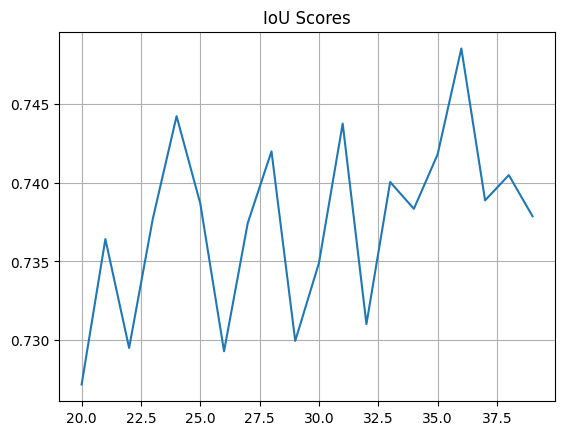

In [34]:
sns.lineplot(x=metrics['epoch'],y=metrics['iou'])
plt.title('IoU Scores')
plt.grid(True)

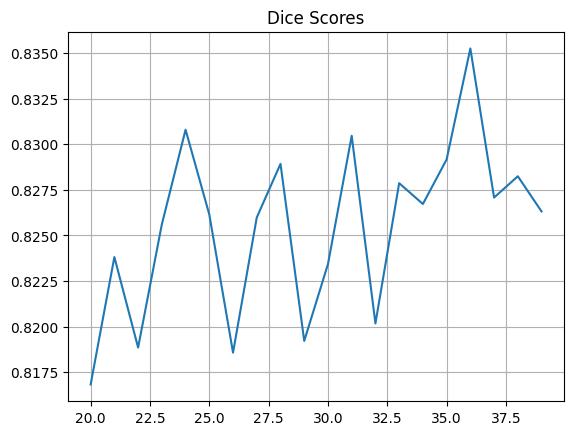

In [35]:
sns.lineplot(x=metrics['epoch'],y=metrics['dice'])
plt.title('Dice Scores')
plt.grid(True)